[*********************100%***********************]  1 of 1 completed


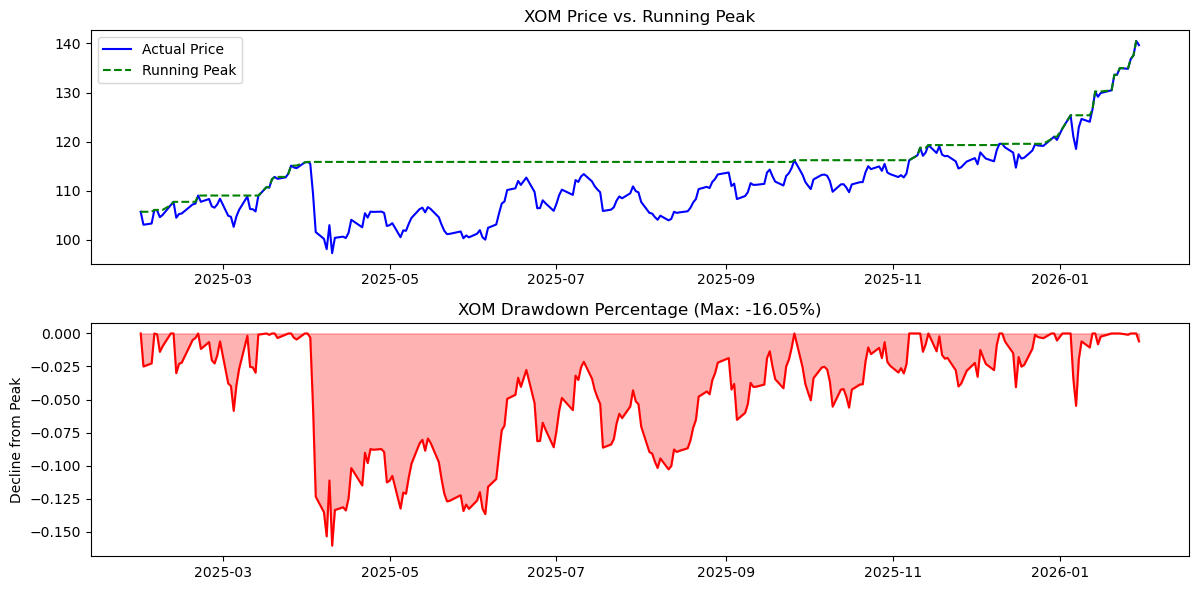

The Maximum Drawdown for XOM over the last year was: -16.05%


In [5]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_max_drawdown_demo(ticker="XOM"):
    # 1. Download 1 year of data
    # We use 'Close' as it's auto-adjusted for dividends in 2026
    data = yf.download(ticker, period="1y")
    
    # 2. Extract the Series and ensure it's 1D
    # This handles the "KeyError" or "DimensionError" from MultiIndex data
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Close'][ticker]
    else:
        prices = data['Close']
    
    # Ensure it's a 1D Series for plotting
    prices = prices.squeeze()

    # 3. Calculate Max Drawdown
    # We find the 'Running Peak' (highest price seen so far)
    rolling_max = prices.cummax()
    
    # Drawdown is the percentage difference from that peak
    drawdown = (prices - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # 4. Visualization
    plt.figure(figsize=(12, 6))

    # Top Plot: Price and Running Peak
    plt.subplot(2, 1, 1)
    plt.plot(prices.index, prices, label="Actual Price", color='blue')
    plt.plot(prices.index, rolling_max, label="Running Peak", color='green', linestyle='--')
    plt.title(f"{ticker} Price vs. Running Peak")
    plt.legend()

    # Bottom Plot: Drawdown "Underwater" Chart
    plt.subplot(2, 1, 2)
    # We use .values to ensure we pass a 1D array to fill_between
    plt.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.3)
    plt.plot(drawdown.index, drawdown.values, color='red')
    plt.title(f"{ticker} Drawdown Percentage (Max: {max_dd:.2%})")
    plt.ylabel("Decline from Peak")
    
    plt.tight_layout()
    plt.show()

    print(f"The Maximum Drawdown for {ticker} over the last year was: {max_dd:.2%}")

# Run the demo
run_max_drawdown_demo("XOM")